In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

In [9]:
file_path = "PLNKU.xlsx"

df = pd.read_excel(file_path)

print("="*70)
print("DATASET AWAL")
print("="*70)

print(df.head())

print("\nJumlah Baris :", df.shape[0])
print("Jumlah Kolom :", df.shape[1])

print("\nNama Kolom:")
print(df.columns)

DATASET AWAL
  PENYULANG    BULAN  TIER1_INPEKSI  TIER1_TEMUAN  TIER2_INPEKSI  \
0      LW05  Januari            0.0           0.0            0.0   
1      AR01  Januari            0.0           0.0            0.0   
2      AR06  Januari            8.0           8.0            0.0   
3      AR07  Januari            0.0           0.0            0.0   
4      AR08  Januari            0.0           0.0            0.0   

   TIER2_TEMUAN  PENGUKURAN  PERGANTIAN_FCO  PENYEIMBANGAN BEBAN GARDU  \
0           0.0         0.0               0                          0   
1           0.0         0.0               0                          0   
2           0.0        10.0               0                          0   
3           0.0        10.0               0                          0   
4           0.0         0.0               0                          0   

   PERBAIKAN GROUNDING TRAFO  PENGHALANG_PANJAT LABEL_RISIKO  
0                          0                0.0       Rendah  
1      

In [10]:
fitur = [
    'TIER1_INPEKSI',
    'TIER1_TEMUAN',
    'TIER2_INPEKSI',
    'TIER2_TEMUAN',
    'PENGUKURAN',
    'PERGANTIAN_FCO',
    'PENYEIMBANGAN BEBAN GARDU',
    'PERBAIKAN GROUNDING TRAFO',
    'PENGHALANG_PANJAT'
]

# Variabel output / target (Y)
target = 'LABEL_RISIKO'

X = df[fitur]
y = df[target]

print("\n" + "="*70)
print("DATA FITUR (X)")
print("="*70)

print(X.head())

print("\n" + "="*70)
print("DATA TARGET (Y)")
print("="*70)

print(y.head())


DATA FITUR (X)
   TIER1_INPEKSI  TIER1_TEMUAN  TIER2_INPEKSI  TIER2_TEMUAN  PENGUKURAN  \
0            0.0           0.0            0.0           0.0         0.0   
1            0.0           0.0            0.0           0.0         0.0   
2            8.0           8.0            0.0           0.0        10.0   
3            0.0           0.0            0.0           0.0        10.0   
4            0.0           0.0            0.0           0.0         0.0   

   PERGANTIAN_FCO  PENYEIMBANGAN BEBAN GARDU  PERBAIKAN GROUNDING TRAFO  \
0               0                          0                          0   
1               0                          0                          0   
2               0                          0                          0   
3               0                          0                          0   
4               0                          0                          0   

   PENGHALANG_PANJAT  
0                0.0  
1                0.0  
2            

In [11]:
print("\n" + "="*70)
print("PROSES NORMALISASI MINMAXSCALER")
print("="*70)

# Rumus:
# X_norm = (X - Xmin) / (Xmax - Xmin)

scaler = MinMaxScaler()

X_normalisasi = scaler.fit_transform(X)

# Mengubah kembali menjadi DataFrame
X_normalisasi = pd.DataFrame(
    X_normalisasi,
    columns=fitur
)

print("\nHASIL NORMALISASI:")
print(X_normalisasi.head())


PROSES NORMALISASI MINMAXSCALER

HASIL NORMALISASI:
   TIER1_INPEKSI  TIER1_TEMUAN  TIER2_INPEKSI  TIER2_TEMUAN  PENGUKURAN  \
0       0.000000      0.000000            0.0           0.0    0.000000   
1       0.000000      0.000000            0.0           0.0    0.000000   
2       0.148148      0.148148            0.0           0.0    0.294118   
3       0.000000      0.000000            0.0           0.0    0.294118   
4       0.000000      0.000000            0.0           0.0    0.000000   

   PERGANTIAN_FCO  PENYEIMBANGAN BEBAN GARDU  PERBAIKAN GROUNDING TRAFO  \
0             0.0                        0.0                        0.0   
1             0.0                        0.0                        0.0   
2             0.0                        0.0                        0.0   
3             0.0                        0.0                        0.0   
4             0.0                        0.0                        0.0   

   PENGHALANG_PANJAT  
0           0.000000  

In [12]:
print("\n" + "="*70)
print("PEMBAGIAN DATA TRAINING DAN TESTING")
print("="*70)

X_train, X_test, y_train, y_test = train_test_split(
    X_normalisasi,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nJumlah Data Training :", len(X_train))
print("Jumlah Data Testing  :", len(X_test))

print("\nX TRAIN:")
print(X_train.head())

print("\nX TEST:")
print(X_test.head())


PEMBAGIAN DATA TRAINING DAN TESTING

Jumlah Data Training : 331
Jumlah Data Testing  : 83

X TRAIN:
     TIER1_INPEKSI  TIER1_TEMUAN  TIER2_INPEKSI  TIER2_TEMUAN  PENGUKURAN  \
121            0.0           0.0            0.0           0.0    0.000000   
126            0.0           0.0            0.0           0.0    0.000000   
397            0.0           0.0            0.0           0.0    0.000000   
240            0.0           0.0            0.0           0.0    0.000000   
196            0.0           0.0            0.0           0.0    0.588235   

     PERGANTIAN_FCO  PENYEIMBANGAN BEBAN GARDU  PERBAIKAN GROUNDING TRAFO  \
121             0.0                       0.00                        0.0   
126             0.0                       0.00                        0.0   
397             0.0                       0.00                        0.0   
240             0.0                       0.25                        0.0   
196             0.0                       0.00     

In [13]:
print("\n" + "="*70)
print("PENCARIAN NILAI K TERBAIK")
print("="*70)

akurasi_k = []

for k in range(1, 16):

    model = KNeighborsClassifier(
        n_neighbors=k,
        metric='euclidean'
    )

    # Training model
    model.fit(X_train, y_train)

    # Prediksi
    y_pred = model.predict(X_test)

    # Hitung akurasi
    akurasi = accuracy_score(y_test, y_pred)

    akurasi_k.append(akurasi)

    print(f"K = {k} --> Accuracy = {akurasi:.4f}")

# Menentukan K terbaik
k_terbaik = np.argmax(akurasi_k) + 1

print("\nK TERBAIK :", k_terbaik)
print("AKURASI TERBAIK :", max(akurasi_k))



PENCARIAN NILAI K TERBAIK
K = 1 --> Accuracy = 0.9639
K = 2 --> Accuracy = 0.9518
K = 3 --> Accuracy = 0.9759
K = 4 --> Accuracy = 0.9518
K = 5 --> Accuracy = 0.9518
K = 6 --> Accuracy = 0.9398
K = 7 --> Accuracy = 0.9398
K = 8 --> Accuracy = 0.9398
K = 9 --> Accuracy = 0.9398
K = 10 --> Accuracy = 0.9157
K = 11 --> Accuracy = 0.9157
K = 12 --> Accuracy = 0.9036
K = 13 --> Accuracy = 0.9036
K = 14 --> Accuracy = 0.9036
K = 15 --> Accuracy = 0.9036

K TERBAIK : 3
AKURASI TERBAIK : 0.9759036144578314



GRAFIK AKURASI SETIAP NILAI K


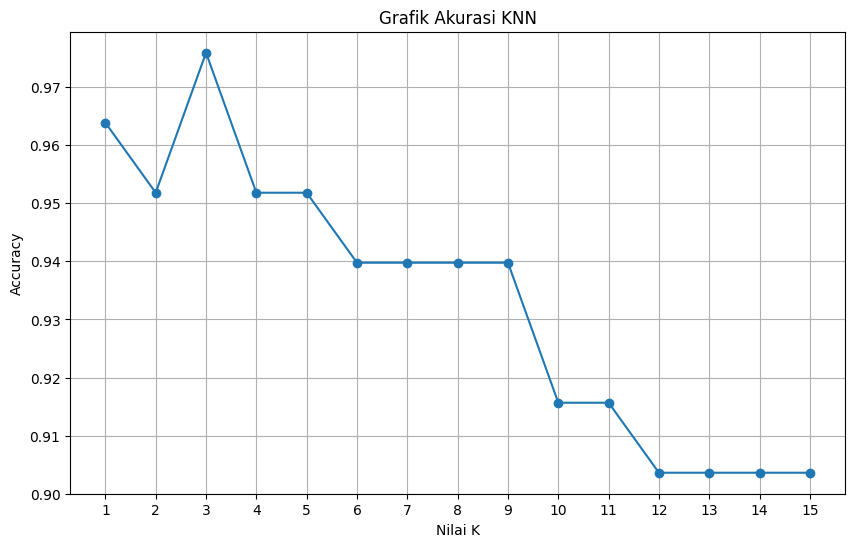

In [14]:
print("\n" + "="*70)
print("GRAFIK AKURASI SETIAP NILAI K")
print("="*70)

plt.figure(figsize=(10,6))

plt.plot(
    range(1,16),
    akurasi_k,
    marker='o'
)

plt.title("Grafik Akurasi KNN")
plt.xlabel("Nilai K")
plt.ylabel("Accuracy")
plt.xticks(range(1,16))
plt.grid(True)

plt.show()

In [ ]:
print("\n" + "="*70)
print("TRAINING MODEL FINAL")
print("="*70)

model_final = KNeighborsClassifier(
    n_neighbors=k_terbaik,
    metric='euclidean'
)

model_final.fit(X_train, y_train)

print("\nModel berhasil dilatih!")



MEMBANGUN MODEL KNN

Model KNN berhasil dilatih dengan K = 3


In [16]:
print("\n" + "="*70)
print("HASIL PREDIKSI")
print("="*70)

y_pred_final = model_final.predict(X_test)

hasil_prediksi = pd.DataFrame({
    'Aktual': y_test.values,
    'Prediksi': y_pred_final
})

print(hasil_prediksi.head(20))



HASIL PREDIKSI
    Aktual Prediksi
0   Rendah   Rendah
1   Rendah   Rendah
2   Rendah   Rendah
3   Sedang   Sedang
4   Sedang   Sedang
5   Rendah   Rendah
6   Rendah   Rendah
7   Sedang   Sedang
8   Tinggi   Tinggi
9   Sedang   Sedang
10  Rendah   Rendah
11  Rendah   Rendah
12  Tinggi   Tinggi
13  Rendah   Rendah
14  Tinggi   Tinggi
15  Sedang   Sedang
16  Tinggi   Tinggi
17  Sedang   Sedang
18  Rendah   Rendah
19  Rendah   Rendah


In [17]:
print("\n" + "="*70)
print("PERHITUNGAN EUCLIDEAN DISTANCE")
print("="*70)

# Mengambil 1 data testing
data_test = X_test.iloc[0].values

# Mengambil 1 data training
data_train = X_train.iloc[0].values

print("\nDATA TEST:")
print(data_test)

print("\nDATA TRAIN:")
print(data_train)

# Rumus Euclidean Distance
# d = sqrt(sum((x1 - x2)^2))

jarak = np.sqrt(np.sum((data_test - data_train) ** 2))

print("\nHASIL EUCLIDEAN DISTANCE:")
print(jarak)


PERHITUNGAN EUCLIDEAN DISTANCE

DATA TEST:
[0. 0. 0. 0. 0. 0. 0. 0. 0.]

DATA TRAIN:
[0. 0. 0. 0. 0. 0. 0. 0. 0.]

HASIL EUCLIDEAN DISTANCE:
0.0


In [18]:
print("\n" + "="*70)
print("TETANGGA TERDEKAT")
print("="*70)

jarak_tetangga, indeks_tetangga = model_final.kneighbors(
    [data_test],
    n_neighbors=k_terbaik
)

print("\nJARAK TETANGGA:")
print(jarak_tetangga)

print("\nINDEX TETANGGA:")
print(indeks_tetangga)

print("\nLABEL TETANGGA:")
print(y_train.iloc[indeks_tetangga[0]].values)


TETANGGA TERDEKAT

JARAK TETANGGA:
[[0. 0. 0.]]

INDEX TETANGGA:
[[29  0  1]]

LABEL TETANGGA:
['Rendah' 'Rendah' 'Rendah']


C:\Users\ASUS\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


In [19]:
print("\n" + "="*70)
print("EVALUASI MODEL")
print("="*70)

# Accuracy
akurasi_final = accuracy_score(y_test, y_pred_final)

print("\nACCURACY:")
print(akurasi_final)



EVALUASI MODEL

ACCURACY:
0.9759036144578314


In [20]:
print("\n" + "="*70)
print("CONFUSION MATRIX")
print("="*70)

cm = confusion_matrix(y_test, y_pred_final)

print(cm)



CONFUSION MATRIX
[[37  0  0]
 [ 0 32  2]
 [ 0  0 12]]


<Figure size 800x600 with 0 Axes>

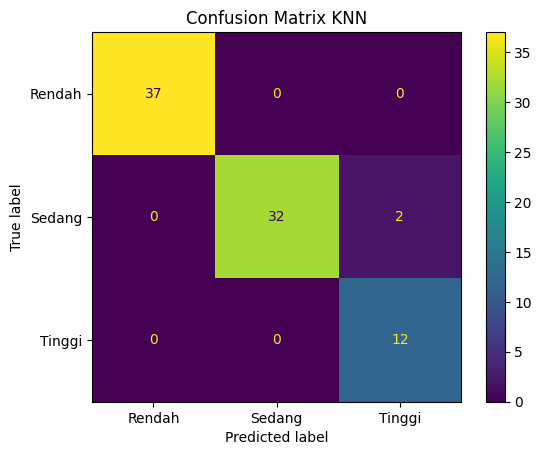

In [21]:
plt.figure(figsize=(8,6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model_final.classes_
)

disp.plot()

plt.title("Confusion Matrix KNN")
plt.show()

In [22]:
print("\n" + "="*70)
print("CLASSIFICATION REPORT")
print("="*70)

print(classification_report(y_test, y_pred_final))


CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Rendah       1.00      1.00      1.00        37
      Sedang       1.00      0.94      0.97        34
      Tinggi       0.86      1.00      0.92        12

    accuracy                           0.98        83
   macro avg       0.95      0.98      0.96        83
weighted avg       0.98      0.98      0.98        83



In [23]:
print("\n" + "="*70)
print("PROBABILITAS PREDIKSI")
print("="*70)

probabilitas = model_final.predict_proba(X_test)

print(probabilitas[:10])



PROBABILITAS PREDIKSI
[[1.         0.         0.        ]
 [1.         0.         0.        ]
 [1.         0.         0.        ]
 [0.         1.         0.        ]
 [0.33333333 0.66666667 0.        ]
 [1.         0.         0.        ]
 [1.         0.         0.        ]
 [0.         1.         0.        ]
 [0.         0.33333333 0.66666667]
 [0.         1.         0.        ]]


In [24]:
print("\n" + "="*70)
print("DATA SALAH PREDIKSI")
print("="*70)

salah_prediksi = hasil_prediksi[
    hasil_prediksi['Aktual'] != hasil_prediksi['Prediksi']
]

print(salah_prediksi)


DATA SALAH PREDIKSI
    Aktual Prediksi
47  Sedang   Tinggi
63  Sedang   Tinggi


In [25]:
print("\n" + "="*70)
print("DATA BENAR PREDIKSI")
print("="*70)

benar_prediksi = hasil_prediksi[
    hasil_prediksi['Aktual'] == hasil_prediksi['Prediksi']
]

print(benar_prediksi.head(20))


DATA BENAR PREDIKSI
    Aktual Prediksi
0   Rendah   Rendah
1   Rendah   Rendah
2   Rendah   Rendah
3   Sedang   Sedang
4   Sedang   Sedang
5   Rendah   Rendah
6   Rendah   Rendah
7   Sedang   Sedang
8   Tinggi   Tinggi
9   Sedang   Sedang
10  Rendah   Rendah
11  Rendah   Rendah
12  Tinggi   Tinggi
13  Rendah   Rendah
14  Tinggi   Tinggi
15  Sedang   Sedang
16  Tinggi   Tinggi
17  Sedang   Sedang
18  Rendah   Rendah
19  Rendah   Rendah
